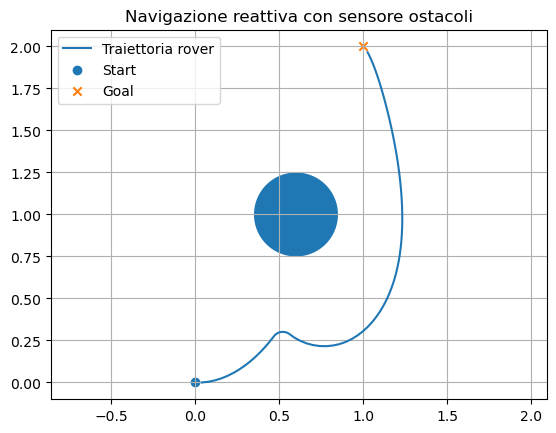

In [40]:
import math
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
dt = 0.1
v_max = 0.4
w_max = 1.2

sensor_range = 0.5      # portata sensore [m]
sensor_fov = math.radians(60)  # campo visivo ±30°

# =========================
# Stato iniziale
# =========================
x, y, theta = 0.0, 0.0, 0.0

# =========================
# Goal
# =========================
x_g, y_g = 1.0, 2.0

# =========================
# Ostacolo (sconosciuto al rover)
# =========================
obs_x, obs_y = 0.6, 1.0
obs_r = 0.25

# =========================
def normalize_angle(a):
    while a > math.pi:
        a -= 2 * math.pi
    while a < -math.pi:
        a += 2 * math.pi
    return a

# =========================
# Simulazione
# =========================
trajectory = []

for _ in range(2000):

    # -------- direzione verso goal --------
    dx_g = x_g - x
    dy_g = y_g - y
    dist_g = math.hypot(dx_g, dy_g)
    angle_goal = math.atan2(dy_g, dx_g)
    goal_error = normalize_angle(angle_goal - theta)

    # -------- sensore ostacolo --------
    dx_o = obs_x - obs_r - x
    dy_o = obs_y - obs_r - y
    dist_o = math.hypot(dx_o, dy_o)
    angle_o = normalize_angle(math.atan2(dy_o, dx_o) - theta)

    obstacle_detected = (
        dist_o < sensor_range
        #and abs(angle_o) < sensor_fov / 2
    )

    # -------- controllo --------
    if obstacle_detected:
        # evita ostacolo
        v = 0.2 * v_max
        w = -w_max if angle_o > 0 else w_max
    else:
        # vai verso goal
        v = min(v_max, dist_g)
        w = max(-w_max, min(w_max, goal_error))

    # -------- integrazione --------
    x += v * math.cos(theta) * dt
    y += v * math.sin(theta) * dt
    theta += w * dt
    theta = normalize_angle(theta)

    trajectory.append((x, y, theta))

    if dist_g < 0.05:
        break

# =========================
# Plot
# =========================
xs = [p[0] for p in trajectory]
ys = [p[1] for p in trajectory]

plt.figure()
plt.plot(xs, ys, label="Traiettoria rover")
plt.scatter(0, 0, label="Start")
plt.scatter(x_g, y_g, marker="x", label="Goal")

# ostacolo (solo per visualizzazione)
circle = plt.Circle((obs_x, obs_y), obs_r)
plt.gca().add_patch(circle)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Navigazione reattiva con sensore ostacoli")

plt.show()

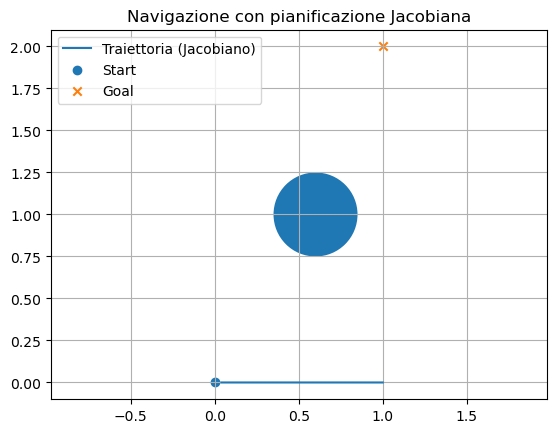

In [49]:
import math
import numpy as np
import matplotlib.pyplot as plt

# =========================
dt = 0.1
v_max = 0.4
w_max = 1.2

# =========================
x, y, theta = 0.0, 0.0, 0.0
x_g, y_g = 1.0, 2.0

# ostacolo (sconosciuto al controllo)
obs_x, obs_y = 0.6, 1.0
obs_r = 0.25

sensor_range = 0.8

# guadagni
k_goal = 0.8
k_obs = 0.4

# =========================
def normalize_angle(a):
    return (a + math.pi) % (2 * math.pi) - math.pi

# =========================
trajectory = []

for _ in range(2000):

    # -------- task goal --------
    dx = x_g - x
    dy = y_g - y
    dist_g = math.hypot(dx, dy)

    xdot_goal = k_goal * np.array([dx, dy])

    # -------- sensore ostacolo --------
    dx_o = obs_x - x
    dy_o = obs_y - y
    dist_o = math.hypot(dx_o, dy_o)

    xdot_obs = np.zeros(2)
    if dist_o < sensor_range:
        angle_o = math.atan2(dy_o, dx_o)
        xdot_obs = -k_obs / (dist_o**2) * np.array([
            math.cos(angle_o),
            math.sin(angle_o)
        ])

    # -------- velocità desiderata --------
    xdot_des = xdot_goal + xdot_obs

    # -------- Jacobiano --------
    J = np.array([
        [math.cos(theta), 0],
        [math.sin(theta), 0]
    ])

    J_pinv = np.linalg.pinv(J)

    u = J_pinv @ xdot_des
    v, w = u[0], u[1]

    v = max(-v_max, min(v_max, v))
    w = max(-w_max, min(w_max, w))

    # -------- integrazione --------
    x += v * math.cos(theta) * dt
    y += v * math.sin(theta) * dt
    theta += w * dt
    theta = normalize_angle(theta)

    trajectory.append((x, y))

    if dist_g < 0.05:
        break

# =========================
# Plot
# =========================
xs, ys = zip(*trajectory)

plt.figure()
plt.plot(xs, ys, label="Traiettoria (Jacobiano)")
plt.scatter(0, 0, label="Start")
plt.scatter(x_g, y_g, marker="x", label="Goal")

# ostacolo (solo per visualizzazione)
circle = plt.Circle((obs_x, obs_y), obs_r)
plt.gca().add_patch(circle)

plt.axis("equal")
plt.grid()
plt.legend()
plt.title("Navigazione con pianificazione Jacobiana")
plt.show()